# Importing Libraries and Loading Data

In [1]:
# Importing Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

In [2]:
# Load Data
df = pd.read_csv(r"C:\Users\majaz\OneDrive\Desktop\E-commerce-segment-project\Customer_segmentation_rawdata.csv", encoding="ISO-8859-1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


# Data Cleaning and Preparation

## Step1: Dataset Overview and Basic Exploration

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [4]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_sales
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France,16.60
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France,14.85


In [5]:
# Basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
 8   Total_sales  541909 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 37.2+ MB


In [6]:
df.shape

(541909, 9)

In [7]:
# Summary statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0
Total_sales,541909.0,17.987795,378.810824,-168469.60,3.40,9.75,17.40,168469.6


In [8]:
# Summary statistics for categorical/text variables
df.describe(include='object').T

,count,unique,top,freq
InvoiceNo,541909,25900,573585,1114
StockCode,541909,4070,85123A,2313
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369
InvoiceDate,541909,23260,10/31/2011 14:41,1114
Country,541909,38,United Kingdom,495478


## Step2: Handling Missing Values

In [9]:
# Calculate the count of null-values for each column
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
Total_sales         0
dtype: int64

In [10]:
# Find total number of rows
len(df)


541909

In [11]:
# Calculate percentage of null values of custid

num=round((df["CustomerID"].isnull().sum()/len(df))*100,2)
print("The percentage of missing values in the CustomerID column is:", num,'%')

The percentage of missing values in the CustomerID column is: 24.93 %


In [12]:
# Removing null-values from the 'CustomerID' column
df=df.dropna(subset=["CustomerID"])

In [13]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France,16.60


In [14]:
# Verifying the removal of missing values 

df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Total_sales    0
dtype: int64

In [15]:
#checking the shape
df.shape

(406829, 9)

## Step3: Handling duplicates

In [16]:
# Check for duplicate rows

duplicates=df.duplicated()

In [17]:
# Count the number of duplicate rows

print(duplicates.sum())

5225


In [18]:
df[duplicates]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_sales
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom,1.25
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom,2.10
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom,2.95
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom,4.95
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom,2.95
...,...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,12/9/2011 11:34,0.39,14446.0,United Kingdom,0.39
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,12/9/2011 11:34,2.49,14446.0,United Kingdom,2.49
541692,581538,22992,REVOLVER WOODEN RULER,1,12/9/2011 11:34,1.95,14446.0,United Kingdom,1.95
541699,581538,22694,WICKER STAR,1,12/9/2011 11:34,2.10,14446.0,United Kingdom,2.10


In [19]:
# remove duplicates,keeping first occerence
df=df.drop_duplicates()

In [20]:
duplicates=df.duplicated()

In [21]:
print(duplicates.sum())

0


In [22]:
# Reset the index after dropping duplicates
# Here drop = True removes the previous indices
df.reset_index(drop=True,inplace=True)

In [23]:
df.shape

(401604, 9)

In [24]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


## Step4: Removing Cancelled Orders

In [25]:
# Count of rows for which quantity is less than 0
df[df["Quantity"]<0].shape[0]

8872

In [26]:
# Exploring the rows for which quantity is less than 0
df[df["Quantity"]<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_sales
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,-6.96
...,...,...,...,...,...,...,...,...,...
401159,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom,-9.13
401243,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom,-224.69
401410,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom,-54.75
401411,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom,-1.25


In [27]:
# Store negative quantity rows in df1
# These will be required if we want to analyse the cancelled orders later
df1_cancelled=df[df["Quantity"]<0]

In [28]:
df1_cancelled.shape

(8872, 9)

In [29]:
# Keep only rows with Quantity ≥ 0 here we removed negative rows from quantity
df=df[df["Quantity"]>=0]

In [30]:
df.shape

(392732, 9)

## Step5: Further exploring the Columns

In [31]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,392732.0,13.153718,181.588420,1.0,2.00,6.00,12.00,80995.00
UnitPrice,392732.0,3.125596,22.240725,0.0,1.25,1.95,3.75,8142.75
CustomerID,392732.0,15287.734822,1713.567773,12346.0,13955.00,15150.00,16791.00,18287.00
Total_sales,392732.0,22.629195,311.083465,0.0,4.95,12.39,19.80,168469.60


In [32]:
df.describe(include='object').T

,count,unique,top,freq
InvoiceNo,392732,18536,576339,542
StockCode,392732,3665,85123A,2023
Description,392732,3877,WHITE HANGING HEART T-LIGHT HOLDER,2016
InvoiceDate,392732,17286,11/14/2011 15:27,542
Country,392732,37,United Kingdom,349227


### Exploring Quantity column

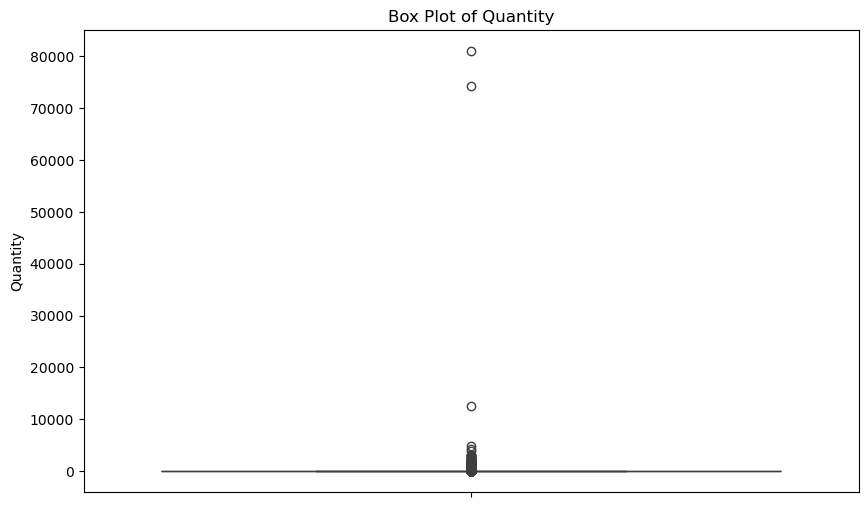

In [33]:
# Boxplot of quantity
plt.figure(figsize=(10, 6))
sns.boxplot(y=df["Quantity"])
plt.title("Box Plot of Quantity")
plt.ylabel("Quantity")
plt.show()

In [34]:
# Checking the details of the order containing maximum quantity
df[df["Quantity"] == 80995]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_sales
401131,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,12/9/2011 9:15,2.08,16446.0,United Kingdom,168469.6


In [35]:
# Checking if this customer has orderd anything else
df[df["CustomerID"] == 16446.0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_sales
135450,553573,22980,PANTRY SCRUBBING BRUSH,1,5/18/2011 9:52,1.65,16446.0,United Kingdom,1.65
135451,553573,22982,PANTRY PASTRY BRUSH,1,5/18/2011 9:52,1.25,16446.0,United Kingdom,1.25
401131,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,12/9/2011 9:15,2.08,16446.0,United Kingdom,168469.60


In [36]:
# Excluding some outliers
df2 = df[df["Quantity"] < 50]
df2.shape

(380234, 9)

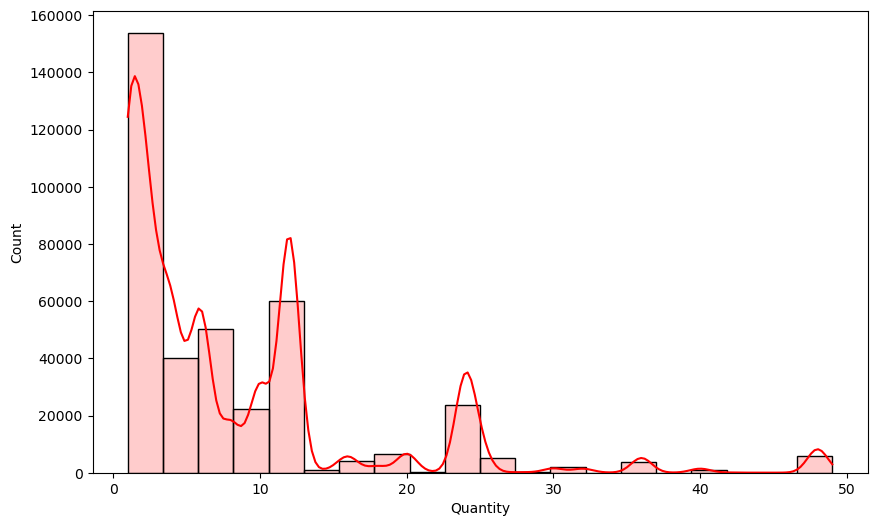

In [37]:
# Hisplot for checking the distribution
plt.figure(figsize=(10, 6))
sns.histplot(df2["Quantity"], bins=20, kde=True, color="red", alpha=0.2)
plt.show()

### Exploring Unit Price column

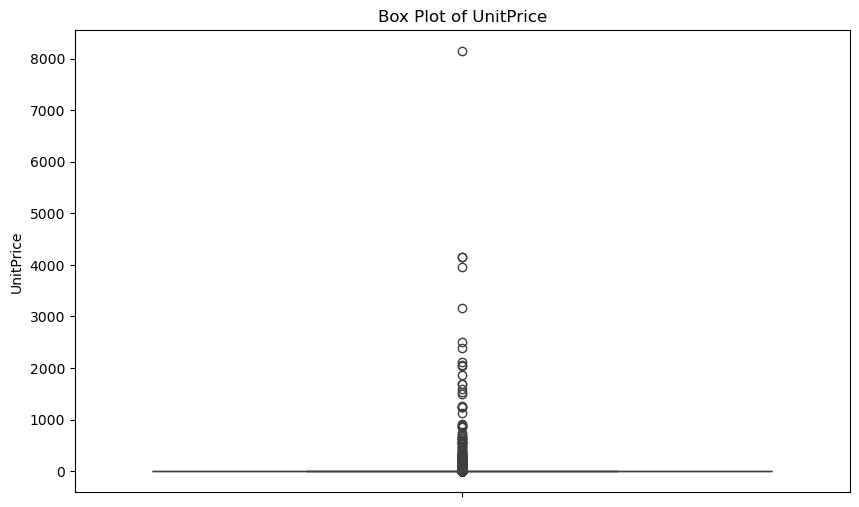

In [38]:
# Boxplot of Unit Price
plt.figure(figsize=(10,6))
sns.boxplot(y=df["UnitPrice"])
plt.title("Box Plot of UnitPrice")
plt.ylabel("UnitPrice")
plt.show()


In [39]:
# Checking the max value of UnitPrice
df["UnitPrice"].max()

8142.75

In [40]:
df[df["UnitPrice"]==8142.75]  #its give the details 

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_sales
119907,551697,POST,POSTAGE,1,5/3/2011 13:46,8142.75,16029.0,United Kingdom,8142.75


In [41]:
df3=df[df["UnitPrice"]<10]
df3.shape

(381920, 9)

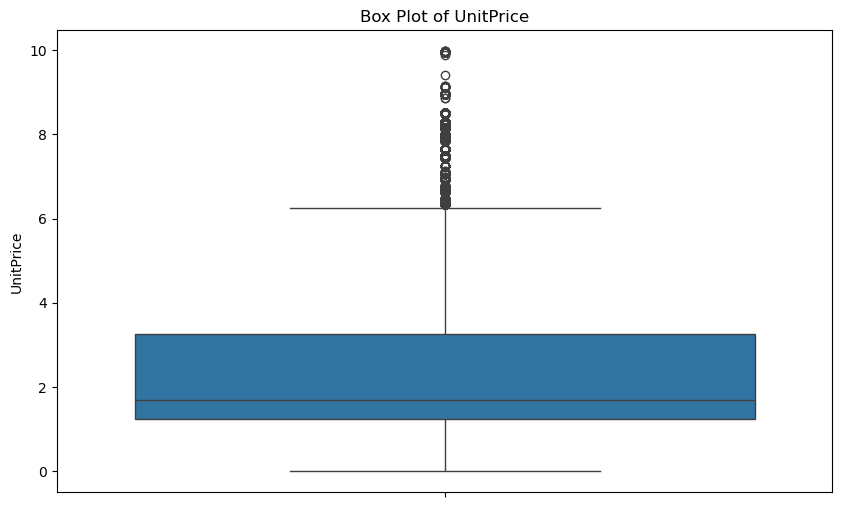

In [42]:
plt.figure(figsize=(10,6))
sns.boxplot(y=df3["UnitPrice"])
plt.title("Box Plot of UnitPrice")
plt.ylabel("UnitPrice")
plt.show()

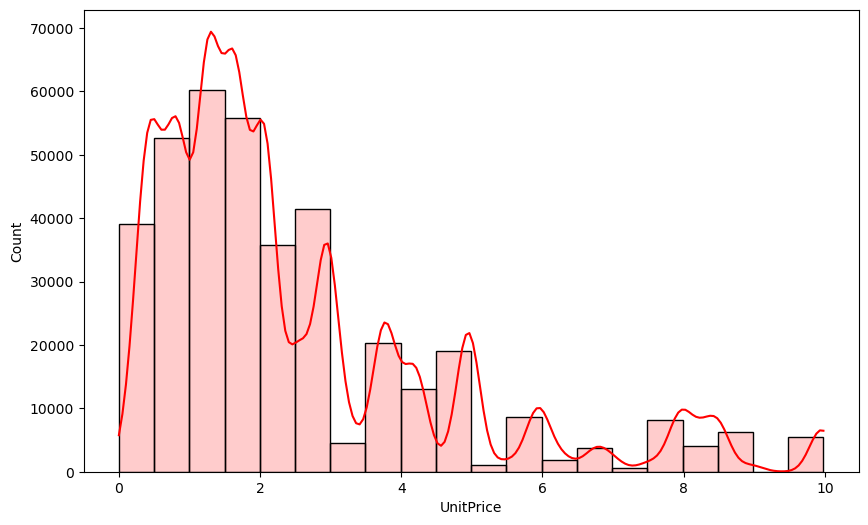

In [43]:
plt.figure(figsize=(10,6))
sns.histplot(df3["UnitPrice"], bins=20, color="red", kde=True, alpha=0.2)
plt.show()

In [44]:
Insights: Most of the orders are low priced products. 

SyntaxError: invalid syntax (2283653034.py, line 1)

### Exploring InvoiceDate

In [ ]:
# Checking the dtype
print(df["InvoiceDate"].dtype)

In [ ]:
#change dt to datetime
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])
print(df["InvoiceDate"].dtype)

In [ ]:
# First and Last order date
print("first order date:",df["InvoiceDate"].min())
print("last order date:",df["InvoiceDate"].max())

### Exploring StockCode

In [ ]:
df.head(10)

In [ ]:
# Checking the numeric StockCodes
df["StockCode"] = df["StockCode"].astype(str)
df[df["StockCode"].str.isnumeric()]

In [ ]:
df.shape

In [ ]:
Insights: Out of 392732 StockCodes, 358309 StockCodes are numeric. 

In [ ]:
numeric_stockcodes=df[df["StockCode"].str.isnumeric()]

In [ ]:
numeric_stockcodes

In [ ]:
# Filter for StockCodes that are entirely numeric
numeric_stockcodes = df[df['StockCode'].str.isnumeric()]

# Calculate the length of each numeric StockCode
numeric_stockcodes['Length'] = numeric_stockcodes['StockCode'].str.len()

# Group by the length and count the occurrences
length_counts = numeric_stockcodes['Length'].value_counts().sort_index()

# View the result
print(length_counts)

In [ ]:
SettingWithCopyWarning: Happens when trying to modify a DataFrame that may be a view/slice of another DataFrame.
Use .copy() when creating a filtered DataFrame to make an independent copy.

In [ ]:
# Checking the alphanumeric StockCodes ""~ sign means not numeric"
df[~df["StockCode"].str.isnumeric()]

In [ ]:
# Filter for StockCodes that are entirely alphanumeric
alphanumeric_stockcodes = df[~df['StockCode'].str.isnumeric()]

# Calculate the length of each aplhanumeric StockCode
alphanumeric_stockcodes['Length'] = alphanumeric_stockcodes['StockCode'].str.len()

# Group by the length and count the occurrences
length__counts = alphanumeric_stockcodes['Length'].value_counts().sort_index()

# View the result
print(length__counts)

In [ ]:
alphanumeric_stockcodes.shape

In [ ]:
# Creating a new column which contains the length of the StockCodes
df["len_sc"] = df["StockCode"].str.len()
df["len_sc"].value_counts()

In [ ]:
df

In [ ]:
# "StockCodes" which have a length less than 5
df[(df["len_sc"] < 5)]["StockCode"].value_counts()

In [ ]:
df_sc = df[(df["len_sc"] < 5)][["StockCode", "Description"]].drop_duplicates()
df_sc

In [ ]:
df[(df["len_sc"] > 7)]["StockCode"].value_counts()

In [ ]:
df[df["StockCode"] == '15056BL'].head(1)

In [ ]:
# Removing all the anomaly stockcodes i.e. stock codes of length 1,2,4,12 
# Keeping only the stockcodes having length 5,6,7
df = df[(df["len_sc"] >= 5) & (df["len_sc"] < 8)]
df["len_sc"].value_counts()

In [ ]:
df.shape

In [ ]:
# Removing the len_sc column
df = df.drop("len_sc", axis=1)
df.shape

In [ ]:
df

### Exploring Description

In [ ]:
df[["StockCode", "Description"]].describe()

In [ ]:
# Identify stock codes with more than one unique description
duplicates = df.groupby('StockCode')['Description'].nunique()
duplicates = duplicates[duplicates > 1].index

In [ ]:
# Filter the rows that have these stock codes
duplicate_rows = df[df['StockCode'].isin(duplicates)]

In [ ]:
# Sort the result by StockCode
duplicate_rows_sorted = duplicate_rows[['StockCode', 'Description']].sort_values(by='StockCode')

In [ ]:
# View the result
print(duplicate_rows_sorted.drop_duplicates())

### Exploring CustomerID

In [ ]:
df["CustomerID"].nunique()

In [ ]:
#"Which 5 customers appear most frequently in my dataset?"
df["CustomerID"].value_counts().head()

### Exploring Country

In [ ]:
df["Country"].nunique()

In [ ]:
df["Country"].value_counts().head(37)

### Exploring InvoiceNo

In [ ]:
df["InvoiceNo"].nunique()

In [ ]:
df["InvoiceNo"].value_counts().head(5)

In [ ]:
df.shape

# EDA

## Time Series Analysis

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df["Total_sales"].describe()

In [ ]:
# We will use this dataframe for the rest of time-series analysis
dft = df.copy()
dft.shape

### Daily Sales Over Time

In [ ]:
#First, make sure InvoiceDate is a datetime:
dft["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [ ]:
dft["InvoiceDate"].dtype

In [ ]:
# Analysing Daily sales 
# Extract the date from the datetime
dft["InvoiceDate"] = dft["InvoiceDate"].dt.date
dft.head()

In [ ]:
daily_sales = dft.groupby("InvoiceDate")["Total_sales"].sum().reset_index()
daily_sales.head()

In [ ]:
# Set figure size
plt.figure(figsize=(12, 6))

# Line plot
sns.lineplot(data=daily_sales, x="InvoiceDate", y="Total_sales", color="royalblue", linewidth=2)

# Labels & Title
plt.xlabel("Date", fontsize=12, fontweight="bold")
plt.ylabel("Total_sales", fontsize=12, fontweight="bold")
plt.title("Daily Sales Trend Over Time", fontsize=14, fontweight="bold", color="darkred")

# Format x-axis to show Month-Year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))  # Jan-2010 format
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # Show every 2nd month

# Format y-axis to show sales in "K" instead of full numbers
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))  # Converts 80,000 → 80K

# Set x-axis limits to start from the first date in the dataset
plt.xlim(df["InvoiceDate"].min(), df["InvoiceDate"].max())

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show grid for better readability
plt.grid(True, linestyle="--", alpha=0.5)

# Show plot
plt.show()


In [ ]:
#chatgpt 
plt.figure(figsize=(12,6))

plt.plot(dft["InvoiceDate"], dft["Total_sales"])

plt.xlabel("Date", fontsize=12, fontweight="bold")
plt.ylabel("Total Sales", fontsize=12, fontweight="bold")
plt.title("Daily Sales Trend Over Time", fontsize=14, fontweight="bold")

plt.show()

In [ ]:
# Resample sales data monthly and sum up the total sales
monthly_sales = df.resample('ME', on="InvoiceDate")["Total_sales"].sum()

# Convert index to formatted string (e.g., "Jan 2010")
monthly_sales.index = monthly_sales.index.strftime('%b %Y')

# Display the result
print(monthly_sales)

In [ ]:
print("The Average monthly sales over a period of one year is", round(monthly_sales.values.mean()))

In [ ]:
plt.figure(figsize=(12, 5))
sns.barplot(x=monthly_sales.index, y=monthly_sales.values, palette="pastel", edgecolor="black")

# Formatting
plt.xlabel("Month-Year", fontsize=12, fontweight="bold")
plt.ylabel("Total Sales", fontsize=12, fontweight="bold")
plt.title("Total Sales Per Month", fontsize=14, fontweight="bold", color="darkblue")

# Format y-axis to show sales in "K" instead of full numbers
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Calculate average monthly sales
average_sales = monthly_sales.values.mean()
# Add a horizontal dotted line for average sales
plt.axhline(average_sales, color="red", linestyle="dotted", linewidth=2, label=f"Avg Sales: {average_sales/1000:.1f}K")


# Add annotation above the average line
plt.text(x=len(monthly_sales) - 6,  # Position near the last bar
         y=average_sales + (average_sales * 0.03),  # Slightly above the line
         s="Average Monthly Sales",
         color="red",
         fontsize=12,
         fontweight="bold",
         ha="right")  # Align to the right

# Rotate x-axis labels
plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

### Sales by Day

In [ ]:
# Analysing Daily sales 
# Extract the day from the datetime
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df.head()

In [ ]:
sales_by_day = df.groupby("DayOfWeek")["Total_sales"].sum().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
sales_by_day

In [ ]:
df[df["DayOfWeek"] == "Saturday"]

In [ ]:
# Set figure size
plt.figure(figsize=(10, 6))

# Create bar plot
sns.barplot(x=sales_by_day.index, y=sales_by_day.values, palette="pastel", edgecolor="black")

# Formatting
plt.xlabel("Day of the Week", fontsize=12, fontweight="bold")
plt.ylabel("Total Sales", fontsize=12, fontweight="bold")
plt.title("Total Sales by Day of the Week", fontsize=14, fontweight="bold", color="blue")

# Format y-axis to show sales in "K" instead of full numbers
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add gridlines for better readability
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Show plot
plt.show()

In [ ]:
df


In [ ]:
df["InvoiceDate"].head()

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [ ]:
df["InvoiceDate"].dtype

In [ ]:
df["InvoiceDate"].head()

In [ ]:
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()

In [ ]:
df["Invoice_Date"] = df["InvoiceDate"].dt.date

In [ ]:
df

In [45]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceDate"].head()

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]

## Pareto Principle

### 80% of the company's revenue comes from 20% of the total customers

In [46]:
df["StockCode"].nunique()

3665

In [47]:
df["CustomerID"].nunique()

4339

In [50]:
# Total sales per customer,groupby() normally makes CustomerID the index. reset_index() turns it back into a normal column
sales_per_customer = df.groupby("CustomerID")["Total_sales"].sum().reset_index() 
sales_per_customer = sales_per_customer.sort_values(by = "Total_sales", ascending=False).reset_index(drop=True)
sales_per_customer

,CustomerID,Total_sales
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194390.79
3,16446.0,168472.50
4,14911.0,143711.17
...,...,...
4334,17956.0,12.75
4335,16454.0,6.90
4336,14792.0,6.20
4337,16738.0,3.75


In [52]:
# Creating a new column "Cumulative Percentage"
sales_per_customer["CumulativePercentage"] = (sales_per_customer["Total_sales"].cumsum()*100)/sales_per_customer["Total_sales"].sum()
sales_per_customer

,CustomerID,Total_sales,CumulativePercentage
0,14646.0,280206.02,3.152914
1,18102.0,259657.30,6.074610
2,17450.0,194390.79,8.261920
3,16446.0,168472.50,10.157594
4,14911.0,143711.17,11.774650
...,...,...,...
4334,17956.0,12.75,99.999810
4335,16454.0,6.90,99.999888
4336,14792.0,6.20,99.999958
4337,16738.0,3.75,100.000000


In [53]:
# Verifying the Pareto Principle
perc = round((len(sales_per_customer[sales_per_customer["CumulativePercentage"] < 80])*100)/len(sales_per_customer))
print(f"{perc}% of customers contribute to 80% of sales.")

26% of customers contribute to 80% of sales.


### 20% of the products are responsible for 80% of the revenue

In [54]:
df["StockCode"].nunique()

3665

In [57]:
# Total sales per product
sales_per_product = df.groupby("StockCode")["Total_sales"].sum().reset_index()
sales_per_product = sales_per_product.sort_values(by="Total_sales", ascending=False).reset_index(drop=True)
sales_per_product

,StockCode,Total_sales
0,23843,168469.600
1,22423,142264.750
2,85123A,100547.450
3,85099B,85040.540
4,23166,81416.730
...,...,...
3660,90084,0.850
3661,90104,0.850
3662,21268,0.840
3663,84227,0.420


In [59]:
# Creating a new column "CumulativePercentage" ,.cumsum() → calculates the running/cumulative sales
sales_per_product["CumulativePercentage"] = (sales_per_product["Total_sales"].cumsum()*100)/sales_per_product["Total_sales"].sum()
sales_per_product

,StockCode,Total_sales,CumulativePercentage
0,23843,168469.600,1.895641
1,22423,142264.750,3.496422
2,85123A,100547.450,4.627795
3,85099B,85040.540,5.584682
4,23166,81416.730,6.500793
...,...,...,...
3660,90084,0.850,99.999976
3661,90104,0.850,99.999986
3662,21268,0.840,99.999995
3663,84227,0.420,100.000000


In [60]:
# Verifying the Pareto Principle
perc = round((len(sales_per_product[sales_per_product["CumulativePercentage"] < 80])*100)/len(sales_per_product))
print(f"{perc}% of products contribute to 80% of sales.")

21% of products contribute to 80% of sales.


### 20% of the products contribute to 80% of the sales volume

In [61]:
# Sales volume per product
volume_per_product = df.groupby("StockCode")["Quantity"].sum().reset_index()
volume_per_product = volume_per_product.sort_values(by="Quantity", ascending=False).reset_index(drop=True)
volume_per_product

,StockCode,Quantity
0,23843,80995
1,23166,77916
2,84077,54319
3,22197,49160
4,85099B,46078
...,...,...
3660,90130A,1
3661,21839,1
3662,21895,1
3663,90128B,1


In [63]:
# Creating a new column "CumulativePercentage"
volume_per_product["CumulativePercentage"] = (volume_per_product["Quantity"].cumsum()*100)/volume_per_product["Quantity"].sum()
volume_per_product

,StockCode,Quantity,CumulativePercentage
0,23843,80995,1.567882
1,23166,77916,3.076162
2,84077,54319,4.127656
3,22197,49160,5.079284
4,85099B,46078,5.971251
...,...,...,...
3660,90130A,1,99.999923
3661,21839,1,99.999942
3662,21895,1,99.999961
3663,90128B,1,99.999981


In [64]:
# Verifying the Pareto Principle
perc = round((len(volume_per_product[volume_per_product["CumulativePercentage"] < 80])*100)/len(volume_per_product))
print(f"{perc}% of products contribute to 80% of sales volume.")

23% of products contribute to 80% of sales volume.


In [66]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
401599,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
401600,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
401601,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
401602,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
